# Εισαγωγή στο Πρόβλημα: Εντοπισμός Πιθανής Φοροδιαφυγής
## Το Πραγματικό Σενάριο (The "Business Problem"):

Φανταστείτε ότι είστε μια φορολογική αρχή (π.χ., η ΑΑΔΕ). Κάθε χρόνο λαμβάνετε εκατομμύρια φορολογικές δηλώσεις. Είναι αδύνατο, λόγω κόστους και χρόνου, να ελέγξετε εξονυχιστικά ("audit") κάθε μία δήλωση ξεχωριστά.

Ο στόχος σας είναι να γίνετε πιο "έξυπνοι": Να χρησιμοποιήσετε τους πόρους σας (τους ελεγκτές σας) όσο το δυνατόν πιο αποτελεσματικά. Αυτό σημαίνει ότι θέλετε να εστιάσετε τους ελέγχους σας σε εκείνες τις δηλώσεις που έχουν τη μεγαλύτερη πιθανότητα να περιέχουν κάποια μορφή φοροδιαφυγής ("Cheat").

## Τα Δεδομένα που Έχουμε (Η "Γνώση" μας):

Για να το κάνετε αυτό, στρέφεστε στο παρελθόν. Έχετε ένα μικρό ιστορικό αρχείο από 10 παλαιότερες υποθέσεις που έχετε ήδη ελέγξει. Για κάθε μία από αυτές τις 10 υποθέσεις, γνωρίζετε:

- Refund (Επιστροφή Φόρου): Αν ο φορολογούμενος ζήτησε επιστροφή φόρου (Ναι/Όχι).

- MaritalStatus (Οικογενειακή Κατάσταση): Αν ήταν Έγγαμος ή Άγαμος.

- TaxableIncome (Φορολογητέο Εισόδημα): Το ποσό του εισοδήματος που δήλωσε.

- **Cheat (Το Αποτέλεσμα)**: Το πιο σημαντικό: Γνωρίζετε το τελικό πόρισμα του ελέγχου – αν δηλαδή αυτός ο άνθρωπος είχε διαπράξει φοροδιαφυγή (Ναι/Όχι).

# Η Ποιοτική Ερώτηση (Ο Στόχος του Μοντέλου):

### Το βασικό ερώτημα που προσπαθούμε να απαντήσουμε είναι:

"Μπορούμε να βρούμε μοτίβα (patterns) ή "κανόνες" μέσα σε αυτά τα 10 παραδείγματα; Υπάρχουν συγκεκριμένοι συνδυασμοί χαρακτηριστικών που 'μαρτυρούν' ύποπτη συμπεριφορά;"

# ==========================================
# Θεωρία - Ο Αλγόριθμος του Hunt
# ==========================================
# Βασική Ιδέα
Ο αλγόριθμος του Hunt είναι μια αναδρομική μέθοδος κατασκευής δέντρου απόφασης:

### 1️⃣ Αν όλες οι εγγραφές στον κόμβο Dt ανήκουν στην ίδια κλάση → το Dt γίνεται φύλλο.
### 2️⃣ Αν το Dt είναι κενό → το φύλλο παίρνει την κλάση πλειοψηφίας του γονέα.
### 3️⃣ Διαφορετικά, επιλέγεται το γνώρισμα A που μεγιστοποιεί το Information Gain ή μειώνει περισσότερο το Gini ή την Entropy.
### 4️⃣ Ο κόμβος χωρίζεται σε παιδιά βάσει των τιμών του A, και ο αλγόριθμος εφαρμόζεται αναδρομικά.

In [ ]:
# ==========================================
# Δημιουργία Δεδομένων
# ==========================================
import pandas as pd

data = {
    'Refund': ['Yes','No','No','No','No','Yes','No','No','No','Yes'],
    'MaritalStatus': ['Single','Married','Single','Single','Married','Married','Married','Single','Single','Married'],
    'TaxableIncome': [125,100,70,120,95,60,220,85,75,90],
    'Cheat': ['Yes','Yes','Yes','No','Yes','Yes','No','No','No','Yes']
}

df = pd.DataFrame(data)
df


,Refund,MaritalStatus,TaxableIncome,Cheat
0,Yes,Single,125,Yes
1,No,Married,100,Yes
2,No,Single,70,Yes
3,No,Single,120,No
4,No,Married,95,Yes
5,Yes,Married,60,Yes
6,No,Married,220,No
7,No,Single,85,No
8,No,Single,75,No
9,Yes,Married,90,Yes


In [ ]:
# ==========================================
# Προεπεξεργασία
# ==========================================
from sklearn import tree

# One-hot encoding για κατηγορικά χαρακτηριστικά
df_encoded = pd.get_dummies(df[['Refund', 'MaritalStatus']])
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
X = pd.concat([df_encoded, df['TaxableIncome']], axis=1)
print(X)
print('-------------------------------------------------------------------------------------------------------')
y = df['Cheat']
print(y)

   Refund_No  Refund_Yes  MaritalStatus_Married  MaritalStatus_Single  TaxableIncome
0      False        True                  False                  True            125
1       True       False                   True                 False            100
2       True       False                  False                  True             70
3       True       False                  False                  True            120
4       True       False                   True                 False             95
5      False        True                   True                 False             60
6       True       False                   True                 False            220
7       True       False                  False                  True             85
8       True       False                  False                  True             75
9      False        True                   True                 False             90
-----------------------------------------------------------------

In [ ]:
# ===============================================================
# Πώς επιλέγει ο Hunt το 1ο χαρακτηριστικό διαχωρισμού
# ===============================================================

from math import log2
import pandas as pd
import numpy as np
from IPython.display import Markdown as md

md(r"""
## 🔍 Επιλογή Πρώτου Κριτηρίου (Χαρακτηριστικού)

Ο αλγόριθμος του Hunt (όπως και ο ID3) επιλέγει **το χαρακτηριστικό που "καθαρίζει" περισσότερο τα δεδομένα**,
δηλαδή αυτό που δίνει το **μεγαλύτερο Information Gain (IG)**.

Η διαδικασία για κάθε υποψήφιο χαρακτηριστικό είναι:

1️⃣ Υπολογίζουμε την **Εντροπία** του αρχικού συνόλου \( D \)
2️⃣ Για κάθε χαρακτηριστικό \( A \), υπολογίζουμε την **αναμενόμενη εντροπία μετά τον διαχωρισμό** (στα υποσύνολα που προκύπτουν από τις τιμές του)
3️⃣ Το **Information Gain** είναι:
$$
IG(D, A) = Entropy(D) - \sum_v \frac{|D_v|}{|D|} \, Entropy(D_v)
$$
4️⃣ Επιλέγεται το χαρακτηριστικό με το **μεγαλύτερο IG**
""")



## 🔍 Επιλογή Πρώτου Κριτηρίου (Χαρακτηριστικού)

Ο αλγόριθμος του Hunt (όπως και ο ID3) επιλέγει **το χαρακτηριστικό που "καθαρίζει" περισσότερο τα δεδομένα**,
δηλαδή αυτό που δίνει το **μεγαλύτερο Information Gain (IG)**.

Η διαδικασία για κάθε υποψήφιο χαρακτηριστικό είναι:

1️⃣ Υπολογίζουμε την **Εντροπία** του αρχικού συνόλου \( D \)
2️⃣ Για κάθε χαρακτηριστικό \( A \), υπολογίζουμε την **αναμενόμενη εντροπία μετά τον διαχωρισμό** (στα υποσύνολα που προκύπτουν από τις τιμές του)
3️⃣ Το **Information Gain** είναι:
$$
IG(D, A) = Entropy(D) - \sum_v \frac{|D_v|}{|D|} \, Entropy(D_v)
$$
4️⃣ Επιλέγεται το χαρακτηριστικό με το **μεγαλύτερο IG**


In [ ]:
# ---------------------------------------------------------------
# Υπολογισμός Εντροπίας και Information Gain για κάθε χαρακτηριστικό
# ---------------------------------------------------------------

def entropy(df, target='Cheat'):
    counts = df[target].value_counts()
    probs = counts / len(df)
    return -sum(p * log2(p) for p in probs if p > 0)

def info_gain(df, feature, target='Cheat'):
    total_entropy = entropy(df, target)
    values = df[feature].unique()
    weighted_entropy = 0
    for v in values:
        subset = df[df[feature] == v]
        weighted_entropy += (len(subset) / len(df)) * entropy(subset, target)
    return total_entropy - weighted_entropy

# Για αριθμητικό χαρακτηριστικό: binary split με threshold (μέσος όρος)
def info_gain_numeric_threshold(df, feature, target='Cheat', threshold=None):
    if threshold is None:
        threshold = df[feature].mean()
    df_low = df[df[feature] <= threshold]
    df_high = df[df[feature] > threshold]
    total_entropy = entropy(df, target)
    weighted_entropy = (len(df_low)/len(df)) * entropy(df_low, target) + \
                       (len(df_high)/len(df)) * entropy(df_high, target)
    return total_entropy - weighted_entropy

# Χρήση:
print("Εντροπία αρχικού συνόλου:", round(entropy(df), 3))
for feature in ['Refund', 'MaritalStatus']:
    print(f"Information Gain για {feature}: {round(info_gain(df, feature), 3)}")
print(f"Information Gain για TaxableIncome (binary split): {round(info_gain_numeric_threshold(df, 'TaxableIncome'), 3)}")



Εντροπία αρχικού συνόλου: 0.971
Information Gain για Refund: 0.281
Information Gain για MaritalStatus: 0.125
Information Gain για TaxableIncome (binary split): 0.091


# Ερμηνεία Αποτελεσμάτων
### Το χαρακτηριστικό με το μεγαλύτερο Information Gain είναι το πρώτο που θα χρησιμοποιηθεί για τον διαχωρισμό.

### Η επιλογή αυτή γίνεται αναδρομικά για κάθε υποσύνολο, ακολουθώντας την ίδια λογική.

## **Συνοψίζοντας**
## Ο Hunt:

### Υπολογίζει την Εντροπία του τρέχοντος κόμβου
### Εξετάζει κάθε χαρακτηριστικό και βρίσκει το IG
### Επιλέγει αυτό με το μεγαλύτερο IG ως πρώτο κριτήριο
### Αυτό επαναλαμβάνεται αναδρομικά για κάθε κόμβο, μέχρι όλοι οι κόμβοι να είναι "καθαροί" (ή να ικανοποιούνται τα κριτήρια τερματισμού).

In [ ]:
# ==========================================
# Εκπαίδευση (Hunt)
# ==========================================
from sklearn import tree

# Εκπαίδευση Decision Tree με Entropy (Information Gain)
model = tree.DecisionTreeClassifier(criterion='entropy', random_state=0)
model.fit(X, y)
print("✅ Εκπαίδευση ολοκληρώθηκε!")


✅ Εκπαίδευση ολοκληρώθηκε!


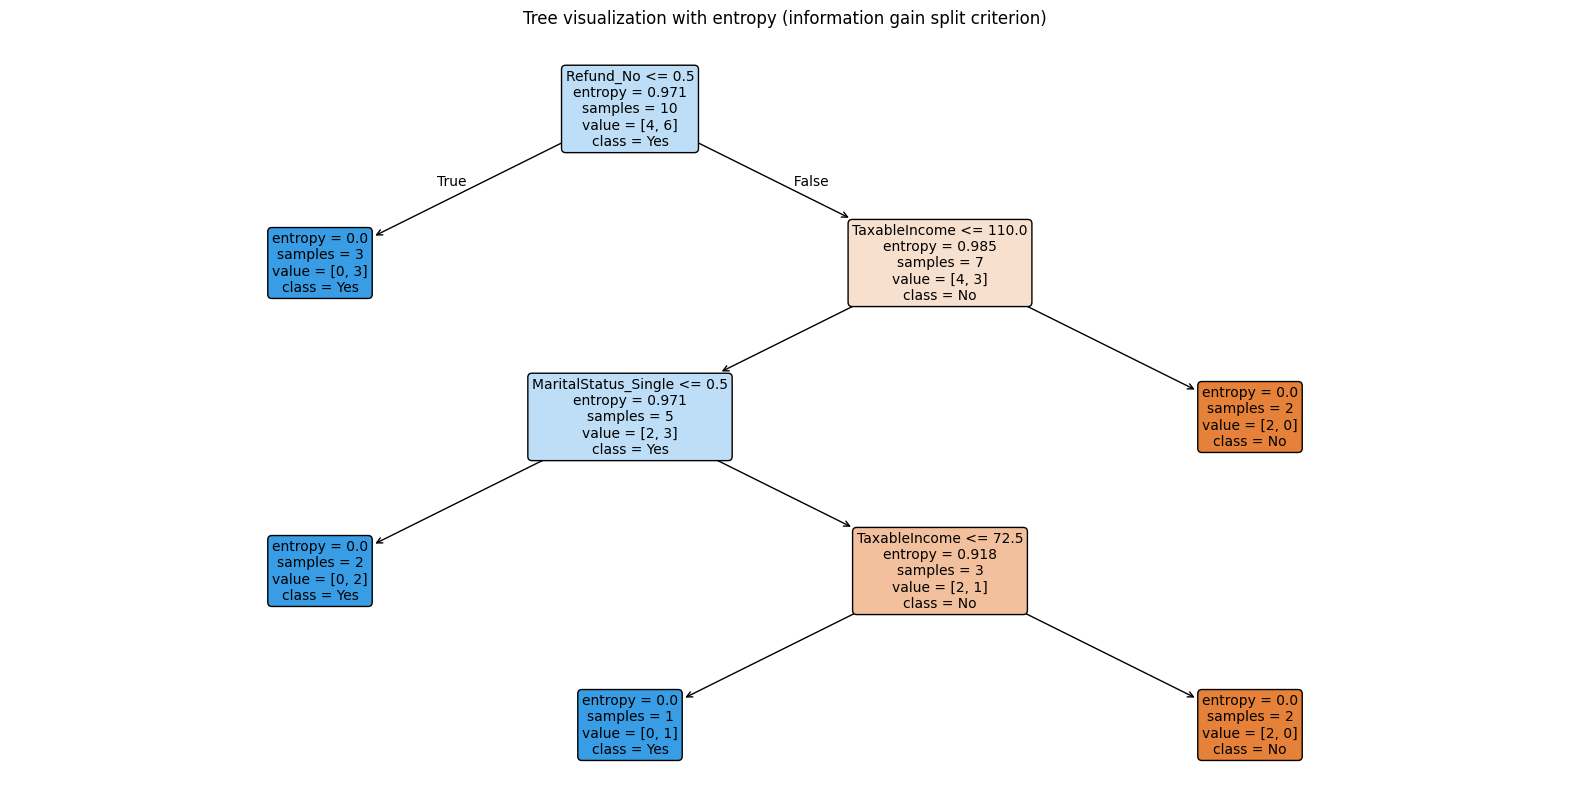

In [ ]:
# ==========================================
# Οπτικοποίηση
# ==========================================

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(20, 10)) # Increase figure size for better readability
plot_tree(model,
          feature_names=X.columns,
          class_names=model.classes_,
          filled=True,
          rounded=True,
          proportion=False, # Set proportion to False to display counts
          fontsize=10) # Decrease font size slightly if needed
plt.title("Tree visualization with entropy (information gain split criterion)")
plt.show()

In [ ]:
# ==========================================
# Δημιουργία πρόβλεψης
# ==========================================

import pandas as pd

# 1. Ορίζουμε τον νέο πελάτη με τα χαρακτηριστικά του
# Δημιουργούμε ένα DataFrame με τα ίδια ονόματα στηλών όπως το X
new_person_data = [[True, False, False, True, 110]] # Corrected values based on previous output and X.columns

new_person_df = pd.DataFrame(new_person_data, columns=X.columns)


# 2. Χρησιμοποιούμε το εκπαιδευμένο μοντέλο για να κάνουμε την πρόβλεψη
prediction = model.predict(new_person_df)

# 3. Τυπώνουμε το αποτέλεσμα
print("Δεδομένα Εισόδου:")
for col, value in new_person_df.iloc[0].items():
    print(f"  {col}: {value}")
print(f"Η πρόβλεψη του μοντέλου είναι: {prediction[0]}")

Δεδομένα Εισόδου:
  Refund_No: True
  Refund_Yes: False
  MaritalStatus_Married: False
  MaritalStatus_Single: True
  TaxableIncome: 110
Η πρόβλεψη του μοντέλου είναι: No
